In [1]:
import pandas as pd

import scarf

scarf.configure_output(level="WARNING", progress=False)

In [2]:
dataset = scarf.cytebase.connect("scarf_docs").download_dataset(
    name="bastidas-ponce_4K_pancreas-d15_rnaseq",
    destination="scarf_datasets",
    zarr=True,
)
ds = scarf.DataStore(
    f"{dataset}/data.zarr",
    nthreads=4,
)
analysis_run = ds.pipeline.open(label="docs_default")
marker_ref = analysis_run["markers"]

ds

DataStore has 3696 (3696) cells with 1 assays: RNA
   Cell metadata:
            'I', 'ids', 'names', 'RNA_percentRibo', 'clusters', 
            'RNA_nCounts', 'RNA_nFeatures', 'RNA_clusters', 'RNA_UMAP1', 'clusters_coarse', 
            'RNA_UMAP2', 'RNA_leiden_cluster', 'RNA_percentMito', 'G2M_score', 'S_score', 
          
   RNA assay has 27998 features and following metadata:
            'I', 'ids', 'names', 'nCells', 'highly_variable_genes', 
            'dropOuts'

In [3]:
cluster_values = analysis_run.cells.fetch("clusters")
pd.Series(cluster_values).value_counts().sort_index()

1     376
2     543
3     610
4     220
5     220
6     373
7     147
8      98
9     551
10    312
11    246
Name: count, dtype: int64

In [4]:
ds.show_zarr_tree(depth=1)

/
├── RNA
│   ├── artifacts
│   ├── counts (3696, 27998) uint16
│   ├── countsT (27998, 3696) uint16
│   └── featureData
├── artifacts
│   ├── cell_selection
│   └── metadata_snapshot
├── cellData
│   ├── G2M_score (3696,) float32
│   ├── I (3696,) bool
│   ├── RNA_UMAP1 (3696,) float32
│   ├── RNA_UMAP2 (3696,) float32
│   ├── RNA_clusters (3696,) int64
│   ├── RNA_leiden_cluster (3696,) int64
│   ├── RNA_nCounts (3696,) float64
│   ├── RNA_nFeatures (3696,) float64
│   ├── RNA_percentMito (3696,) float64
│   ├── RNA_percentRibo (3696,) float64
│   ├── S_score (3696,) float32
│   ├── clusters (3696,) <U13
│   ├── clusters_coarse (3696,) <U13
│   ├── ids (3696,) <U16
│   └── names (3696,) <U16
└── pipeline
    └── runs



In [5]:
ds.show_zarr_tree(start="cellData")

/cellData
├── G2M_score (3696,) float32
├── I (3696,) bool
├── RNA_UMAP1 (3696,) float32
├── RNA_UMAP2 (3696,) float32
├── RNA_clusters (3696,) int64
├── RNA_leiden_cluster (3696,) int64
├── RNA_nCounts (3696,) float64
├── RNA_nFeatures (3696,) float64
├── RNA_percentMito (3696,) float64
├── RNA_percentRibo (3696,) float64
├── S_score (3696,) float32
├── clusters (3696,) <U13
├── clusters_coarse (3696,) <U13
├── ids (3696,) <U16
└── names (3696,) <U16

  RNA_percentRibo: shape=(3696,), dtype=float64, chunks=(100000,)
  names: shape=(3696,), dtype=<U16, chunks=(100000,)
  clusters: shape=(3696,), dtype=<U13, chunks=(100000,)
  I: shape=(3696,), dtype=bool, chunks=(100000,)
  RNA_nFeatures: shape=(3696,), dtype=float64, chunks=(100000,)
  ids: shape=(3696,), dtype=<U16, chunks=(100000,)
  RNA_nCounts: shape=(3696,), dtype=float64, chunks=(100000,)
  clusters_coarse: shape=(3696,), dtype=<U13, chunks=(100000,)
  RNA_UMAP1: shape=(3696,), dtype=float32, chunks=(100000,)
  RNA_clusters: sha

In [6]:
ds.cells.to_pandas_dataframe(["I"])["I"].value_counts()

I
True    3696
Name: count, dtype: int64

In [7]:
ds.show_zarr_tree(start="RNA", depth=1)

/RNA
├── artifacts
│   ├── ann_index
│   ├── cluster_labels
│   ├── cluster_selection
│   ├── connectivity_map
│   ├── embedding
│   ├── embedding_initialization
│   ├── feature_scaling
│   ├── feature_selection
│   ├── feature_summary
│   ├── marker_table
│   ├── metadata_snapshot
│   ├── neighbors
│   ├── normalized
│   └── reduction
├── counts (3696, 27998) uint16
├── countsT (27998, 3696) uint16
└── featureData
    ├── I (27998,) bool
    ├── dropOuts (27998,) int64
    ├── highly_variable_genes (27998,) <U5
    ├── ids (27998,) <U15
    ├── nCells (27998,) int64
    └── names (27998,) <U15

  countsT: shape=(27998, 3696), dtype=uint16, chunks=(27056, 1848), shards=(27056, 3696)
  counts: shape=(3696, 27998), dtype=uint16, chunks=(3696, 13528), shards=(3696, 40584)


In [8]:
ds.show_zarr_tree(start="RNA/featureData", depth=1)

/RNA/featureData
├── I (27998,) bool
├── dropOuts (27998,) int64
├── highly_variable_genes (27998,) <U5
├── ids (27998,) <U15
├── nCells (27998,) int64
└── names (27998,) <U15

  names: shape=(27998,), dtype=<U15, chunks=(100000,)
  highly_variable_genes: shape=(27998,), dtype=<U5, chunks=(100000,)
  nCells: shape=(27998,), dtype=int64, chunks=(100000,)
  I: shape=(27998,), dtype=bool, chunks=(100000,)
  ids: shape=(27998,), dtype=<U15, chunks=(100000,)
  dropOuts: shape=(27998,), dtype=int64, chunks=(100000,)


In [9]:
ds.show_zarr_tree(start="RNA/artifacts", depth=1)

/RNA/artifacts
├── ann_index
│   └── a5a3693061e19acf82ec32fd310a7b8172fac824b8e5c89b99efc2880be91d54
├── cluster_labels
│   └── 8a72d4e1a0dff3ce62e90ac122848679c3c63b296267671622e25d86003e05e5
├── cluster_selection
│   └── a7621eab8b86238ec44c63ebc8c1fed7e35a7f2c2e78382d2ae1127dcb280349
├── connectivity_map
│   └── 32af9516e0327a427faa8e15e6430bad036cdd6ec9b16e44bf0a7955632bf587
├── embedding
│   └── f1b291fd40ae74325a9de09e2ef1e6df2c7a0ca1eb4759bdc330a610d656865c
├── embedding_initialization
│   └── 997150eea81adc98adf797a0989156873da6d1fcba0eb0a0ab776569f053151d
├── feature_scaling
│   └── d1237c7e0f895132c0e3cfc470e932e835ae52b8655add57791e33efc1c5072a
├── feature_selection
│   ├── b99855184bbc2acc6d13527a509a3e4a96adde651cd70450503ea9df12d82ea6
│   └── c7e20c8be3045c757c86a7e958010cbf00682af7dc51e11c1d230044eb3663b9
├── feature_summary
│   └── f6f4536cfd6ffaa94225f1b77a34b8753fc9ccacf3a8cdea3da16412a8387982
├── marker_table
│   └── e0a609c439c19b9a3f4d517ceb80b35414dc9170cb398f888

In [10]:
ds.cells.head()

,I,ids,names,clusters,RNA_nCounts,RNA_nFeatures,RNA_percentRibo,clusters_coarse,RNA_UMAP1,S_score,G2M_score,RNA_leiden_cluster,RNA_clusters,RNA_UMAP2,RNA_percentMito
0,True,AAACCTGAGAGGGATA,AAACCTGAGAGGGATA,Pre-endocrine,4954.0,2356.0,15.563181,Pre-endocrine,-18.330648,-0.224902,-0.252071,1,1,-3.510440,0.706500
1,True,AAACCTGAGCCTTGAT,AAACCTGAGCCTTGAT,Ductal,7071.0,2613.0,30.632160,Ductal,14.409112,-0.014707,-0.232610,2,2,1.015646,1.286947
2,True,AAACCTGAGGCAATTA,AAACCTGAGGCAATTA,Alpha,4070.0,1984.0,19.041769,Endocrine,-12.839149,-0.171255,-0.286834,3,3,-4.816881,0.687961
3,True,AAACCTGCATCATCCC,AAACCTGCATCATCCC,Ductal,8362.0,2860.0,28.653432,Ductal,13.758335,0.599244,0.191243,4,4,-10.900358,1.195886
4,True,AAACCTGGTAAGTGGC,AAACCTGGTAAGTGGC,Ngn3 high EP,5026.0,2211.0,19.419021,Ngn3 high EP,-11.565331,-0.179981,-0.126030,6,6,11.105976,1.094310


In [11]:
ds.RNA.feats.head()

,I,ids,names,nCells,highly_variable_genes,dropOuts
0,True,Xkr4,Xkr4,6,False,3690
1,True,Gm37381,Gm37381,0,,3696
2,True,Rp1,Rp1,0,,3696
3,True,Rp1-1,Rp1-1,0,,3696
4,True,Sox17,Sox17,0,,3696


In [12]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "RNA_nCounts", "RNA_nFeatures", "clusters"]
).set_index("ids")

,RNA_nCounts,RNA_nFeatures,clusters
ids,,,
AAACCTGAGAGGGATA,4954.0,2356.0,Pre-endocrine
AAACCTGAGCCTTGAT,7071.0,2613.0,Ductal
AAACCTGAGGCAATTA,4070.0,1984.0,Alpha
AAACCTGCATCATCCC,8362.0,2860.0,Ductal
AAACCTGGTAAGTGGC,5026.0,2211.0,Ngn3 high EP
...,...,...,...
TTTGTCAAGTGACATA,9219.0,3283.0,Pre-endocrine
TTTGTCAAGTGTGGCA,7298.0,2605.0,Ngn3 high EP
TTTGTCAGTTGTTTGG,5234.0,2168.0,Ductal


In [13]:
first_run_cluster = cluster_values[0]
is_first_cluster = cluster_values == first_run_cluster
ds.cells.insert(
    column_name="is_first_cluster",
    values=is_first_cluster,
    overwrite=True,
)

In [14]:
ds.cells.to_pandas_dataframe(
    columns=["ids", "clusters", "is_first_cluster"]
).head()

,ids,clusters,is_first_cluster
0,AAACCTGAGAGGGATA,Pre-endocrine,True
1,AAACCTGAGCCTTGAT,Ductal,False
2,AAACCTGAGGCAATTA,Alpha,False
3,AAACCTGCATCATCCC,Ductal,False
4,AAACCTGGTAAGTGGC,Ngn3 high EP,False


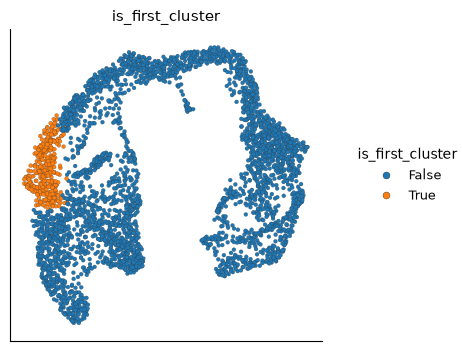

In [15]:
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by="is_first_cluster",
)

In [16]:
print(
    "fetch:", ds.cells.fetch("clusters", key="is_first_cluster").shape,
    "fetch_all:", ds.cells.fetch_all("clusters").shape,
)

fetch: (376,) fetch_all: (3696,)


In [17]:
live_backup = ds.cells.fetch_all("I").copy()
ds.cells.update_key(is_first_cluster, "I")
print("Narrowed:", int(ds.cells.fetch_all("I").sum()))
ds.cells.insert(column_name="I", values=live_backup, overwrite=True, force=True)
print("Reverted:", int(ds.cells.fetch_all("I").sum()))

Narrowed: 376
Reverted: 3696


In [18]:
ds.cells.update_key(is_first_cluster, "I")
print("Narrowed:", int(ds.cells.fetch_all("I").sum()))
ds.cells.reset_key("I")
print("After reset_key:", int(ds.cells.fetch_all("I").sum()))

Narrowed: 376
After reset_key: 3696


In [19]:
if "in_count_range" in ds.cells.columns:
    ds.cells.drop("in_count_range")
else:
    print("in_count_range not present yet; created in section 3")
print("is_first_cluster" in ds.cells.columns)

in_count_range not present yet; created in section 3
True


In [20]:
# Undo the practice column from this section. Re-run the insert cell above to bring it back.
if "is_first_cluster" in ds.cells.columns:
    ds.cells.drop("is_first_cluster")
print("is_first_cluster present after drop:", "is_first_cluster" in ds.cells.columns)

is_first_cluster present after drop: False


In [21]:
# Restore it for the rest of this page. Re-derive from the run so alignment stays correct.
first_run_cluster = cluster_values[0]
is_first_cluster = cluster_values == first_run_cluster
ds.cells.insert(column_name="is_first_cluster", values=is_first_cluster, overwrite=True)
print("Restored:", "is_first_cluster" in ds.cells.columns)

Restored: True


In [22]:
active_before = int(ds.cells.fetch_all("I").sum())
count_range = ds.cells.sift(
    "RNA_nCounts",
    min_v=1000,
    max_v=15000,
)
joint_range = ds.cells.multi_sift(
    columns=["RNA_nCounts", "RNA_nFeatures"],
    lows=[1000, 500],
    highs=[15000, 4000],
)
ductal_rows = ds.cells.get_index_by(["Ductal"], "clusters")

print(
    "count_range:", int(count_range.sum()),
    "joint_range:", int(joint_range.sum()),
    "ductal_rows:", int(ductal_rows.size),
)
print("Active cells (I) before:", active_before)
print("Active cells (I) after:", int(ds.cells.fetch_all("I").sum()))

count_range: 3669 joint_range: 3667 ductal_rows: 916
Active cells (I) before: 3696
Active cells (I) after: 3696


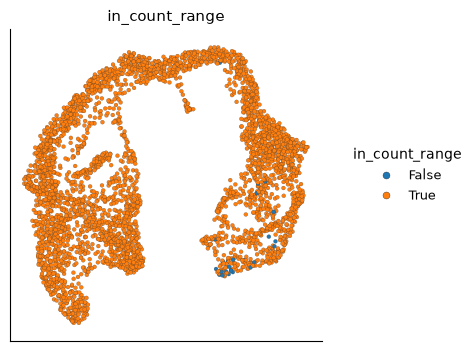

In [23]:
ds.cells.insert(column_name="in_count_range", values=count_range, overwrite=True)
ds.plots.embedding(
    layout=analysis_run["umap"],
    color_by="in_count_range",
)

In [24]:
print("Raw shape:", ds.RNA.rawData.shape)
print("Normed shape:", ds.RNA.normed().shape)
ds.RNA.rawData[:3, :5].compute()

Raw shape: (3696, 27998)
Normed shape: (3696, 27998)


array([[0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0]], dtype=uint16)

In [25]:
ds.RNA.normed()[:3, :5].compute()

array([[0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0.]])

In [26]:
reused_normalized = ds.run_normalization(
    analysis_run["analysis_cell_selection"],
    analysis_run["highly_variable_features"],
)
print("Reused:", reused_normalized == analysis_run["normalized"])
reused_normalized

Reused: True


ArtifactRef(assay='RNA', kind='normalized', artifact_id='66d1ae705957...')

In [27]:
status = ds.inspect_artifact(reused_normalized)
print("Complete:", status.complete)
print("Operation:", status.operation)
print("Parameters:", status.parameters)

group = ds.load_artifact(reused_normalized)
print("Arrays:", list(group.array_keys())[:5])

Complete: True
Operation: run_normalization
Parameters: {'normalization_method': {'external_hook': True, 'module': 'scarf.assay', 'qualname': 'norm_lib_size'}, 'size_factor': 1000.0, 'log_transform': True, 'renormalize_subset': True}
Arrays: ['feature_sum', 'data', 'feature_squared_sum']


In [28]:
ds.get_markers(
    marker=marker_ref,
    group_id=cluster_values[0],
    min_score=0.1,
    min_frac_exp=0.1,
).head()

,group_id,feature_name,feature_index,score,mean,mean_rest,frac_exp,frac_exp_rest,fold_change,p_value,auc,p_value_adjusted
0,1,Blnk,11524,0.46019,0.05631,0.00667,0.22872,0.03855,8.44295,2.293566e-53,0.59779,1.003363e-50
1,1,Cyp4b1,16233,0.45564,0.06387,0.00884,0.25000,0.04639,7.22289,7.984109e-53,0.60422,3.386956e-50
2,1,Vdr,8144,0.44380,0.12882,0.02028,0.43617,0.09639,6.35294,6.585922e-85,0.67983,9.219632e-82
3,1,Gm2694,24369,0.43771,0.05623,0.00662,0.17553,0.02982,8.49279,1.153621e-39,0.57409,2.428502e-37
4,1,Slc25a35,4329,0.42911,0.03421,0.00216,0.14894,0.01295,15.87053,8.150431e-55,0.56851,4.003434e-52


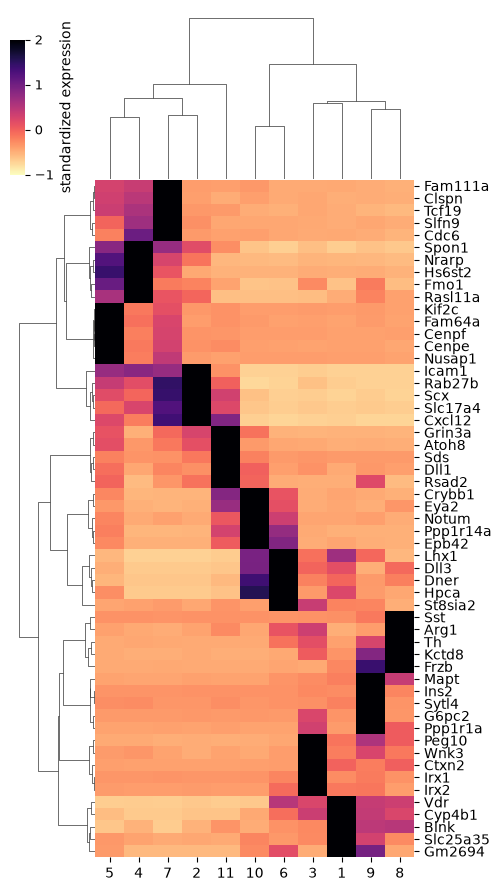

In [29]:
ds.plots.marker_heatmap(
    marker=marker_ref,
    topn=5,
    figsize=(5, 9),
)

In [30]:
markers_csv = "scarf_datasets/pancreas_cluster_markers.csv"
ds.export_markers_to_csv(
    marker=marker_ref,
    csv_filename=markers_csv,
    min_score=0.1,
    min_frac_exp=0.1,
)
pd.read_csv(markers_csv).iloc[:5, :6]

,1,10,11,2,3,4
0,Blnk,Notum,Dll1,Scx,Irx1,Nrarp
1,Cyp4b1,Epb42,Atoh8,Slc17a4,Irx2,Fmo1
2,Vdr,Eya2,Grin3a,Icam1,Ctxn2,Hs6st2
3,Gm2694,Crybb1,Sds,Rab27b,Wnk3,Rasl11a
4,Slc25a35,Ppp1r14a,Rsad2,Cxcl12,Peg10,Spon1
